# Flow Matching 

In [26]:
# Imports and setup
import base64
import functools
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from tqdm import tqdm

sns.set_style("darkgrid")  # Set the style of the plots
pd.options.display.float_format = "{:,.3f}".format  # Table display format

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(626)

# PyTorch Device configuration
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


## Toy example of 1D data transport
Given distribution 0: N(0,1), and distribution 1: a simple bimodal distribution, we will use FM to learn the velocity field of d0 -> d1. 

### Step 1: Defining the distributions and sample pairs

In [37]:
# Define 1D bimodal target distribution
mixture_prob = np.array([0.55, 0.45], dtype=float)  # Mixture weights
mixture_mus = np.array([-0.85, 1.5], dtype=float)  # Means of the two Gaussian modes
mixture_sigmas = np.array([0.65, 0.25], dtype=float)  # Standard deviations of the modes


def mixture_pdf(x: np.ndarray) -> np.ndarray:
    """Compute the PDF of a mixture of Gaussians."""
    comps = scipy.stats.norm.pdf(x[None, :], loc=mixture_mus[:, None], scale=mixture_sigmas[:, None])
    return np.sum(mixture_prob[:, None] * comps, axis=0)


def mixture_sample(size: int) -> np.ndarray:
    """Sample from a mixture of Gaussians."""
    rand_idx = np.random.choice(range(len(mixture_prob)), size=size, p=mixture_prob)
    means = mixture_mus[rand_idx]
    stds = mixture_sigmas[rand_idx]
    return np.random.normal(loc=means, scale=stds)


In [38]:
# --- Step 1: Sample paired (X0, X1) ---
N = 2000
X0 = np.random.randn(N)     # noise samples from N(0,1)
X1 = mixture_sample(N)      # target samples from bimodal mixture

### Step 2: Use straight line reference paths

1. for each pair, we use the straight line as a reference path between them. 
2. Note instead of x1-x0, we used `interpolate_linear(pair, t)` function, which computes x_t at any explicit t. (but the line is essentially just x1-x0)

Text(0.5, 1.0, 'Target Distribution $\\pi_1$')

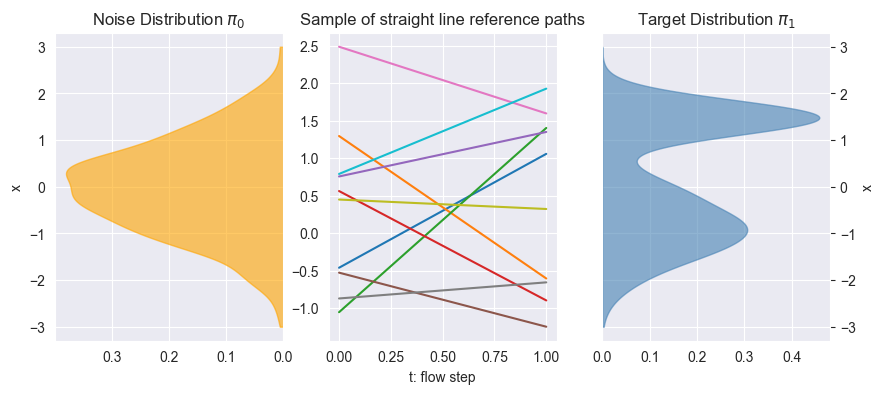

In [40]:
# --- Linear interpolation path ---
def interpolate_linear(x_0, x_1, t):
    """Evaluates the linear interpolation path between x_0 and x_1 at step t."""
    return (1 - t) * x_0 + t * x_1

t_steps = np.linspace(0, 1, 100)
x_range = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
ax = axes[0]
kde0 = gaussian_kde(X0)
ax.fill_betweenx(x_range, kde0(x_range), alpha=0.6, color='orange')
ax.set_xlim(left=0)
ax.invert_xaxis()
ax.set_ylabel('x')
ax.set_title(r'Noise Distribution $\pi_0$')

# Top-middle: Sample of straight-line reference paths
ax = axes[1]
idx = np.random.choice(N, 10, replace=False)
for i in idx:
    path = [interpolate_linear(X0[i], X1[i], t) for t in t_steps]
    ax.plot(t_steps, path)
ax.set_xlabel('t: flow step')
ax.set_title(r'Sample of straight line reference paths')

# Top-right: Target distribution KDE (vertical, x on y-axis, mirrored)
ax = axes[2]
kde1 = gaussian_kde(X1)
ax.fill_betweenx(x_range, kde1(x_range), alpha=0.6, color='steelblue')
ax.set_xlim(left=0)
ax.yaxis.set_label_position('right')
ax.yaxis.tick_right()
ax.set_ylabel('x')
ax.set_title(r'Target Distribution $\pi_1$')

### Sample velocities

Given any pair, the true velocity is v(x_t, t), should be x1-x0, becuase that's the fastest way to get from x0 to x1. 

In [41]:
def get_target_velocity(x_0, x_1):
    """
    Get the velocity for a given pair of noise and target points.
    This is the per-pair (conditional) velocity along the straight path.
    """
    return x_1 - x_0

### Step 3: Training

Components:
1. A consistent reference path (straight line) that start at `x_0` and end at `x_1`, so that we can evaluate `x_t` given `x0`, `x1`, and `t`. (Consistency means all samples need to use this same path).
2. The FM_theta(x_t, t) model that takes `x_t`(data_dim vector) and `t`(scalar 0~1), feed into whatever architecture (MLP in this case), to generate `v_pred`.
3. The target velocity v(x_t, t), this should equal to the derivative of the reference path at `x_t`. 

In training, get a set of (X_0, X_1) as training data:
1. forward: for each pair (x0, x1), sample a random t, calculate x_t, then calculate FM(x_t, t).
2. Compute loss: MSE of (FM(x_t, t), target velocity at x_t)
3. Back propagate.

In [47]:
class FlowMatchingModel(nn.Module):
    """
    Flow Matching model to predict the velocity field at time t and position x_t.
    """

    def __init__(self, data_dim: int, hidden_dim: int) -> None:
        super().__init__()
        # Simple MLP
        self.net: nn.Sequential = nn.Sequential(
            nn.Linear(data_dim + 1, hidden_dim),  # +1 for time embedding
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, data_dim),
        )

    def forward(
        self,
        t: torch.Tensor,  # Denoising step [batch_size, 1]
        x_t: torch.Tensor,  # Interpolated samples [batch_size, data_dim]
    ) -> torch.Tensor:  # [batch_size, data_dim]
        """
        Predicts the velocity field at time t and position x_t.
        """
        tx: torch.Tensor = torch.cat([t, x_t], dim=-1)
        return self.net(tx)

In [48]:
def compute_loss(
    flow_matching_model: FlowMatchingModel,
    x_0: torch.Tensor,
    x_1: torch.Tensor,
    t: torch.Tensor,
) -> torch.Tensor:
    """
    Compute the loss for a single batch of (X_0, X_1) couplings and flow steps T.
    """
    # Interpolate the data at the sampled time step
    x_t = interpolate_linear(x_0=x_0, x_1=x_1, t=t)
    # Get the target velocity
    v_target = get_target_velocity(x_0=x_0, x_1=x_1)
    # Predict the velocity
    v_pred = flow_matching_model(t=t, x_t=x_t)
    # Compute the loss
    loss = ((v_pred - v_target) ** 2).mean()
    return loss

In [50]:
# Train the flow matching model

# Hyperparameters
data_dim: int = 1  # 1D data
hidden_dim: int = 64
nb_train_iterations: int = 1000
lr: float = 1e-3
batch_size: int = 256

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(626)

# Initialize the vector field network and optimizer
flow_matching_model = FlowMatchingModel(data_dim=data_dim, hidden_dim=hidden_dim).to(DEVICE).train()
optimizer = optim.Adam(flow_matching_model.parameters(), lr=lr)

# Training loop
losses: list[float] = []
with tqdm(range(nb_train_iterations), desc="Training", unit="iteration") as progress_bar:
    for i in progress_bar:
        # Sample a batch of target and noise samples
        x_1 = torch.from_numpy(mixture_sample(size=batch_size)).to(dtype=torch.float32, device=DEVICE).unsqueeze(-1)
        x_0 = torch.randn_like(x_1) 
        # Sample a random time step for each sample in the batch
        t = torch.rand(x_1.shape[0], device=DEVICE).unsqueeze(-1)

        # Compute the loss
        loss = compute_loss(flow_matching_model=flow_matching_model, x_0=x_0, x_1=x_1, t=t)

        # Backpropagate the loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        progress_bar.set_postfix({"Loss": f"{loss.item():.2f}"})

Training: 100%|██████████| 1000/1000 [00:00<00:00, 1257.77iteration/s, Loss=1.55]


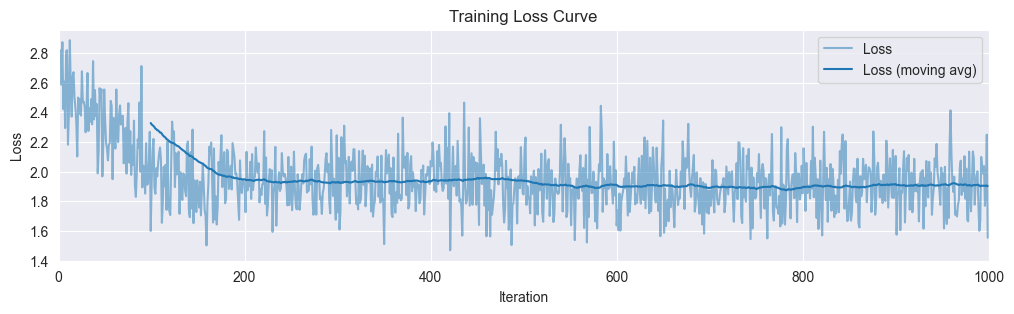

In [51]:
# Plot loss curve after training
fig, ax = plt.subplots(figsize=(12, 3), dpi=100)
ax.plot(losses, color="tab:blue", alpha=0.5, label="Loss")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Curve")
# Plot a smoothed loss curve using a simple moving average
window_size = 100
smoothed_losses = np.convolve(losses, np.ones(window_size) / window_size, mode="valid")
ax.plot(np.arange(window_size - 1, len(losses)), smoothed_losses, color="tab:blue", label="Loss (moving avg)")
ax.legend(loc="upper right")
ax.set_xlim(0, len(losses))
ax.grid(True)
plt.show()
del fig, ax, window_size, smoothed_losses

### Inference

Here we have a ODE: dx/dt = FM(x_t, t). We use Euler's method to integrate this from 0 to 1, so we do :
x_{t + dt} = x_t + FM(x_t, t) * dt
This is **Euler's method**.

In [ ]:
# we can sample a new staring point and let it follow the FM(x_t, t) model velocity field to reach the target distribution
# Illustration on how to sample x_1 from x_0 using the learned velocity field
nb_steps = 10
path_x = np.zeros(nb_steps + 1)  # Array to store the full sampled path
t_steps = np.linspace(0, 1, nb_steps + 1)  # Steps $t$ in the range [0, 1]

# x_0 starting point (Pre-selected here for the example, but ideally x_0 ~ N(0, I
x_0 = torch.Tensor([[0.85]]).to(DEVICE)

with torch.inference_mode():
    flow_matching_model.eval()
    x_t = x_0  # Initialize the sample at the starting point
    path_x[0] = x_t.squeeze().cpu().numpy()
    # Integrate the velocity field using Euler integration from t=0 to t=1
    for i in range(nb_steps):
        t = t_steps[i]  # Current step $t$
        dt = t_steps[i + 1] - t_steps[i]  # Step size
        t_batch = torch.Tensor([[t]]).to(DEVICE)  # Expand the step to a batch dimension
        x_t = x_t + flow_matching_model(t=t_batch, x_t=x_t) * dt # update x_t
        path_x[i + 1] = x_t.squeeze().cpu().numpy()


display(HTML(pd.DataFrame({"t": t_steps, "x": path_x}).transpose().to_html()))

,0,1,2,3,4,5,6,7,8,9,10
t,0.000,0.100,0.200,0.300,0.400,0.500,0.600,0.700,0.800,0.900,1.000
x,0.850,0.772,0.737,0.738,0.772,0.835,0.925,1.040,1.175,1.324,1.484
